# 📊 DataPulse — Task 3: Data Visualization & Task 4: Sentiment Analysis
### CodeAlpha Data Science Internship
**Dataset:** Flipkart Laptop Listings (Scraped & Cleaned)  
**Task 3:** Transform raw data into compelling visual stories using Matplotlib & Seaborn  
**Task 4:** Sentiment Analysis using NLP techniques (VADER + TextBlob)

---

## 📦 Step 1 — Import Libraries

In [20]:
# ── Core ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# ── NLP / Sentiment ───────────────────────────────────────────
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import re

# ── Plot theme ────────────────────────────────────────────────
plt.rcParams['figure.figsize']  = (14, 6)
plt.rcParams['font.size']       = 12
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
sns.set_style('whitegrid')
PALETTE = sns.color_palette('Set2')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 2 — Load Dataset

In [21]:
# ── Load the cleaned dataset (update path if needed) ──────────
df = pd.read_csv('../data/flipkart_laptops_cleaned.csv')

# ── Ensure price segment column exists ────────────────────────
def price_segment(price):
    if pd.isna(price):       return 'Unknown'
    elif price < 30_000:     return 'Budget (< ₹30K)'
    elif price < 60_000:     return 'Mid-Range (₹30K-₹60K)'
    elif price < 1_00_000:   return 'Premium (₹60K-₹1L)'
    else:                    return 'Ultra Premium (> ₹1L)'

df['Price Segment'] = df['Selling Price (INR)'].apply(price_segment)

print(f'✅ Dataset loaded!')
print(f'📌 Shape : {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded!
📌 Shape : 793 rows × 9 columns


,Brand,Product Name,Selling Price (INR),Original Price (INR),Discount (%),Rating,Number of Ratings,Number of Reviews,Price Segment
0,Acer,Acer TravelLite AMD Ryzen 5 7430U - (16 GB/512...,44990,50000.0,10.0,3.8,125.0,11.0,Mid-Range (₹30K-₹60K)
1,HP,HP Victus Intel Core i5 13th Gen 13420H - (16 ...,72990,81201.0,10.0,4.3,733.0,50.0,Premium (₹60K-₹1L)
2,ASUS,ASUS Vivobook Go 15 AMD Ryzen 5 Quad Core 7520...,38990,50990.0,23.0,4.3,1532.0,77.0,Mid-Range (₹30K-₹60K)
3,Lenovo,Lenovo IdeaPad Slim 5 WUXGA OLED Full Metal Bo...,59990,97290.0,38.0,4.4,85.0,11.0,Mid-Range (₹30K-₹60K)
4,Lenovo,Lenovo IdeaPad Slim 3 AMD Ryzen 7 Octa Core 88...,70990,94890.0,25.0,4.4,78.0,7.0,Premium (₹60K-₹1L)


---
# 🎨 TASK 3 — DATA VISUALIZATION
---

## 📊 Visualization 1 — Executive Dashboard (Multi-Panel Overview)

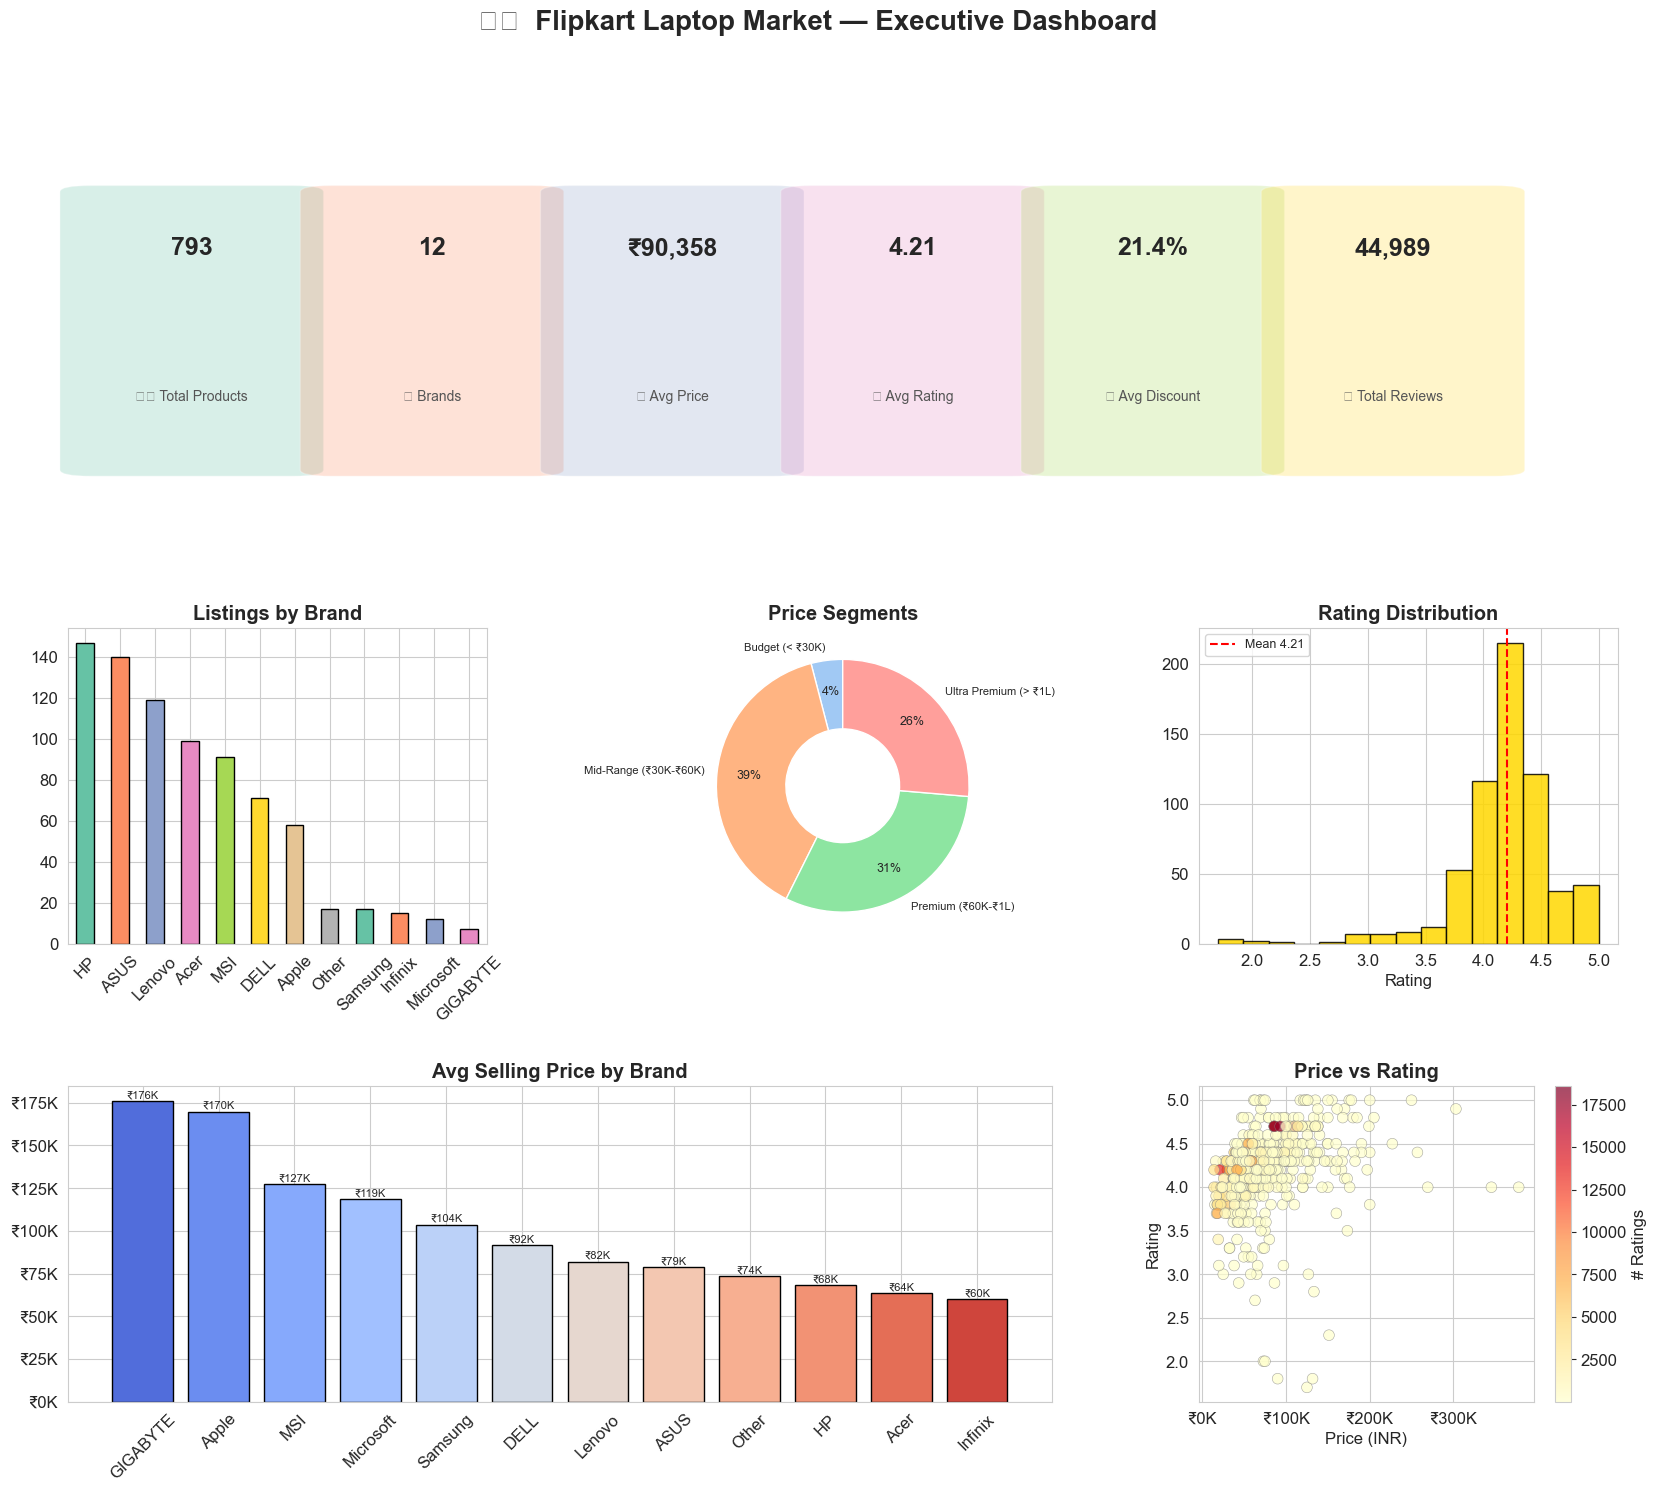

✅ Executive Dashboard saved!


In [22]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('🖥️  Flipkart Laptop Market — Executive Dashboard',
             fontsize=20, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1A. KPI Cards (top row) ────────────────────────────────────
kpi_ax = fig.add_subplot(gs[0, :])
kpi_ax.axis('off')
kpis = [
    ('🏷️ Total Products',   f"{len(df):,}"),
    ('🏢 Brands',           f"{df['Brand'].nunique()}"),
    ('💰 Avg Price',        f"₹{df['Selling Price (INR)'].mean():,.0f}"),
    ('⭐ Avg Rating',       f"{df['Rating'].mean():.2f}"),
    ('🔖 Avg Discount',     f"{df['Discount (%)'].mean():.1f}%"),
    ('📝 Total Reviews',    f"{df['Number of Reviews'].sum():,.0f}"),
]
for i, (label, value) in enumerate(kpis):
    x = 0.08 + i * 0.155
    kpi_ax.add_patch(mpatches.FancyBboxPatch(
        (x - 0.065, 0.05), 0.13, 0.88,
        boxstyle='round,pad=0.02',
        facecolor=PALETTE[i % len(PALETTE)], alpha=0.25,
        transform=kpi_ax.transAxes, clip_on=False))
    kpi_ax.text(x, 0.75, value,  ha='center', va='center',
                fontsize=18, fontweight='bold', transform=kpi_ax.transAxes)
    kpi_ax.text(x, 0.28, label, ha='center', va='center',
                fontsize=10, color='#555', transform=kpi_ax.transAxes)

# ── 1B. Brand distribution bar ────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
brand_cnt = df['Brand'].value_counts()
brand_cnt.plot(kind='bar', ax=ax1,
               color=sns.color_palette('Set2', len(brand_cnt)), edgecolor='k')
ax1.set_title('Listings by Brand', fontweight='bold')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)

# ── 1C. Price segment donut ───────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
seg_order   = ['Budget (< ₹30K)', 'Mid-Range (₹30K-₹60K)',
               'Premium (₹60K-₹1L)', 'Ultra Premium (> ₹1L)']
seg_counts  = df['Price Segment'].value_counts().reindex(seg_order, fill_value=0)
wedges, texts, autotexts = ax2.pie(
    seg_counts, labels=seg_counts.index,
    autopct='%1.0f%%', startangle=90,
    colors=sns.color_palette('pastel', 4),
    wedgeprops=dict(width=0.55), pctdistance=0.75)
for t in texts:     t.set_fontsize(8)
for t in autotexts: t.set_fontsize(9)
ax2.set_title('Price Segments', fontweight='bold')

# ── 1D. Rating distribution histogram ────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
df_r = df.dropna(subset=['Rating'])
ax3.hist(df_r['Rating'], bins=15, color='gold',
         edgecolor='k', alpha=0.85)
ax3.axvline(df_r['Rating'].mean(), color='red',
            linestyle='--', label=f'Mean {df_r["Rating"].mean():.2f}')
ax3.set_title('Rating Distribution', fontweight='bold')
ax3.set_xlabel('Rating')
ax3.legend(fontsize=9)

# ── 1E. Avg price by brand ────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0:2])
bp = df.groupby('Brand')['Selling Price (INR)'].mean().sort_values(ascending=False)
bars = ax4.bar(bp.index, bp.values,
               color=sns.color_palette('coolwarm', len(bp)), edgecolor='k')
for bar in bars:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'₹{bar.get_height()/1000:.0f}K',
             ha='center', va='bottom', fontsize=8)
ax4.set_title('Avg Selling Price by Brand', fontweight='bold')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax4.tick_params(axis='x', rotation=45)

# ── 1F. Price vs Rating scatter ───────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
df_sc = df.dropna(subset=['Selling Price (INR)', 'Rating', 'Number of Ratings'])
sc = ax5.scatter(df_sc['Selling Price (INR)'], df_sc['Rating'],
                 c=df_sc['Number of Ratings'], cmap='YlOrRd',
                 alpha=0.7, s=60, edgecolors='grey', linewidths=0.4)
fig.colorbar(sc, ax=ax5, label='# Ratings')
ax5.set_title('Price vs Rating', fontweight='bold')
ax5.set_xlabel('Price (INR)')
ax5.set_ylabel('Rating')
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.savefig('images/viz1_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Executive Dashboard saved!')

## 📊 Visualization 2 — Brand Battle: Price, Discount & Rating Heatmap

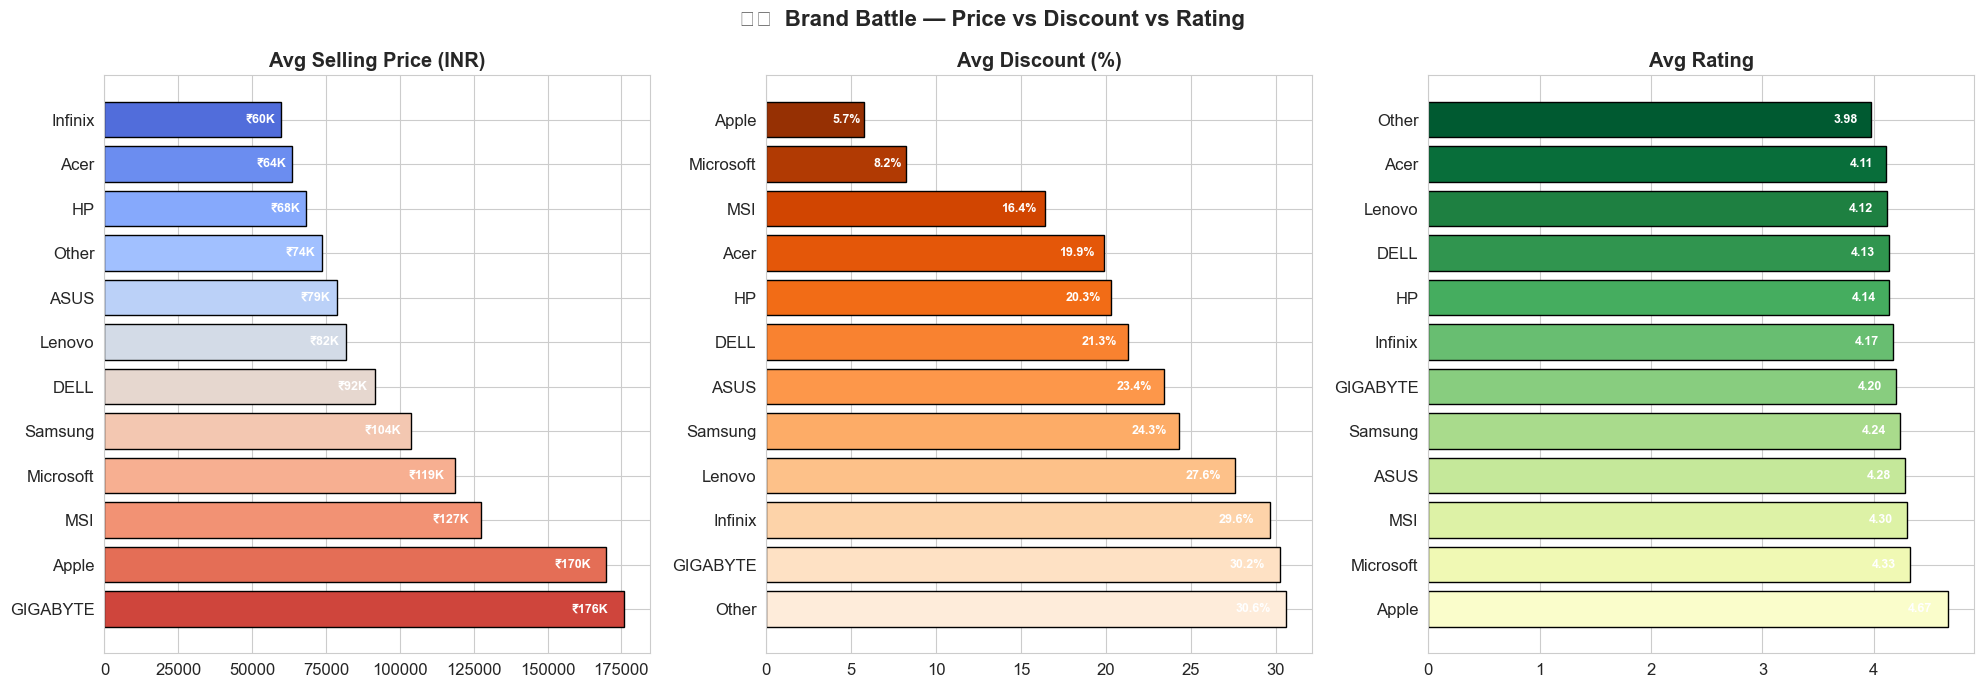

✅ Brand Battle chart saved!


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('⚔️  Brand Battle — Price vs Discount vs Rating',
             fontsize=16, fontweight='bold')

metrics = [
    ('Selling Price (INR)', axes[0], 'coolwarm_r',
     'Avg Selling Price (INR)', lambda v: f'₹{v/1000:.0f}K'),
    ('Discount (%)',         axes[1], 'Oranges',
     'Avg Discount (%)',        lambda v: f'{v:.1f}%'),
    ('Rating',               axes[2], 'YlGn',
     'Avg Rating',             lambda v: f'{v:.2f}'),
]

for col, ax, cmap, title, fmt in metrics:
    brand_vals = df.groupby('Brand')[col].mean().sort_values(ascending=False).dropna()
    bars = ax.barh(brand_vals.index, brand_vals.values,
                   color=sns.color_palette(cmap, len(brand_vals)),
                   edgecolor='k')
    for bar in bars:
        ax.text(bar.get_width() * 0.97, bar.get_y() + bar.get_height()/2,
                fmt(bar.get_width()),
                ha='right', va='center', fontsize=9, color='white', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('images/viz2_brand_battle.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Brand Battle chart saved!')

## 📊 Visualization 3 — Price vs Discount Bubble Chart

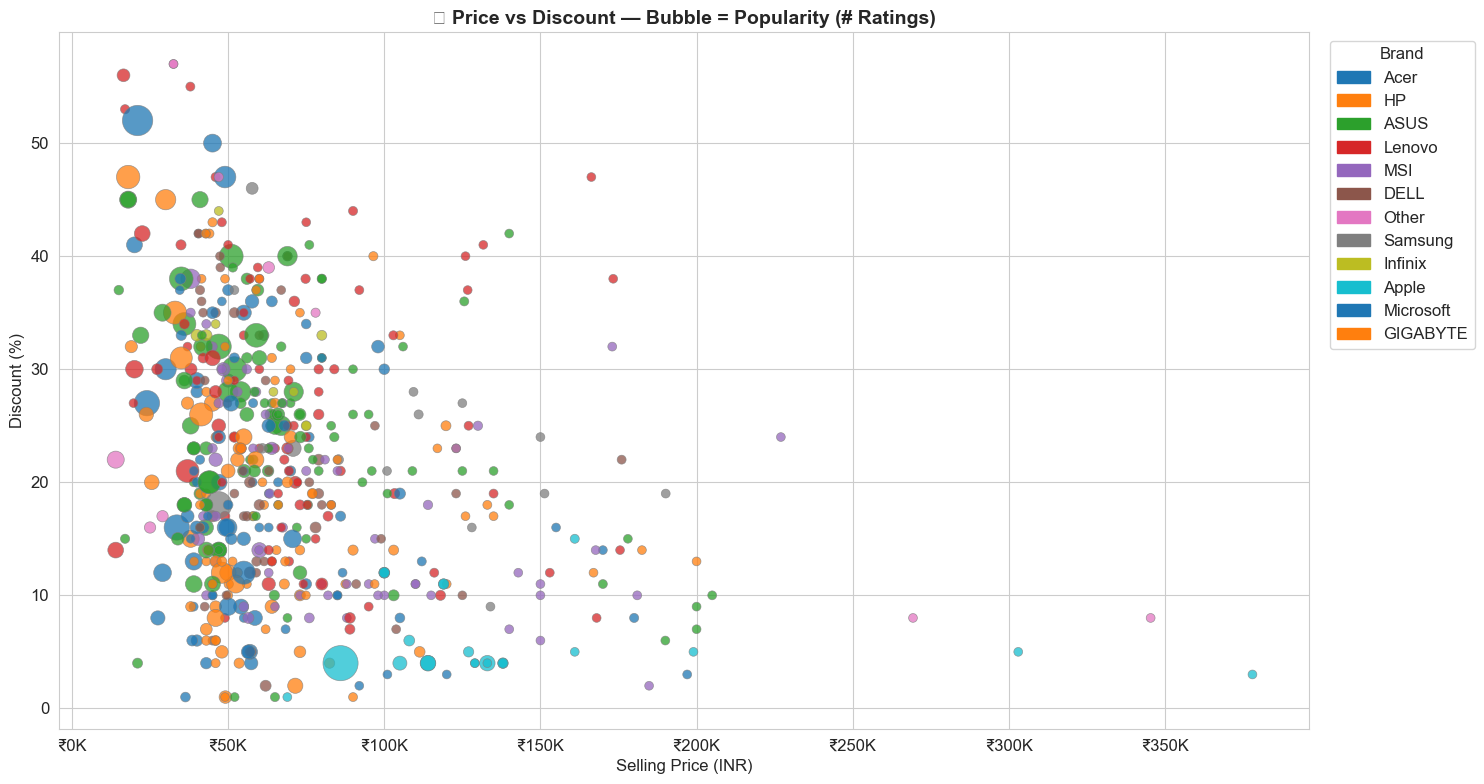

✅ Bubble Chart saved!


In [24]:
df_b = df.dropna(subset=['Selling Price (INR)', 'Discount (%)', 'Rating', 'Number of Ratings'])

# Normalise bubble size
size = (df_b['Number of Ratings'] / df_b['Number of Ratings'].max()) * 600 + 40

brands   = df_b['Brand'].unique()
colors   = dict(zip(brands, sns.color_palette('tab10', len(brands))))
brand_colors = df_b['Brand'].map(colors)

fig, ax = plt.subplots(figsize=(15, 8))
sc = ax.scatter(
    df_b['Selling Price (INR)'], df_b['Discount (%)'],
    s=size, c=brand_colors, alpha=0.75, edgecolors='grey', linewidths=0.5)

# Legend for brands
handles = [mpatches.Patch(color=colors[b], label=b) for b in brands]
ax.legend(handles=handles, title='Brand', bbox_to_anchor=(1.01, 1), loc='upper left')

ax.set_title('💰 Price vs Discount — Bubble = Popularity (# Ratings)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Selling Price (INR)')
ax.set_ylabel('Discount (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('images/viz3_price_vs_discount_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Bubble Chart saved!')

## 📊 Visualization 4 — Correlation Heatmap

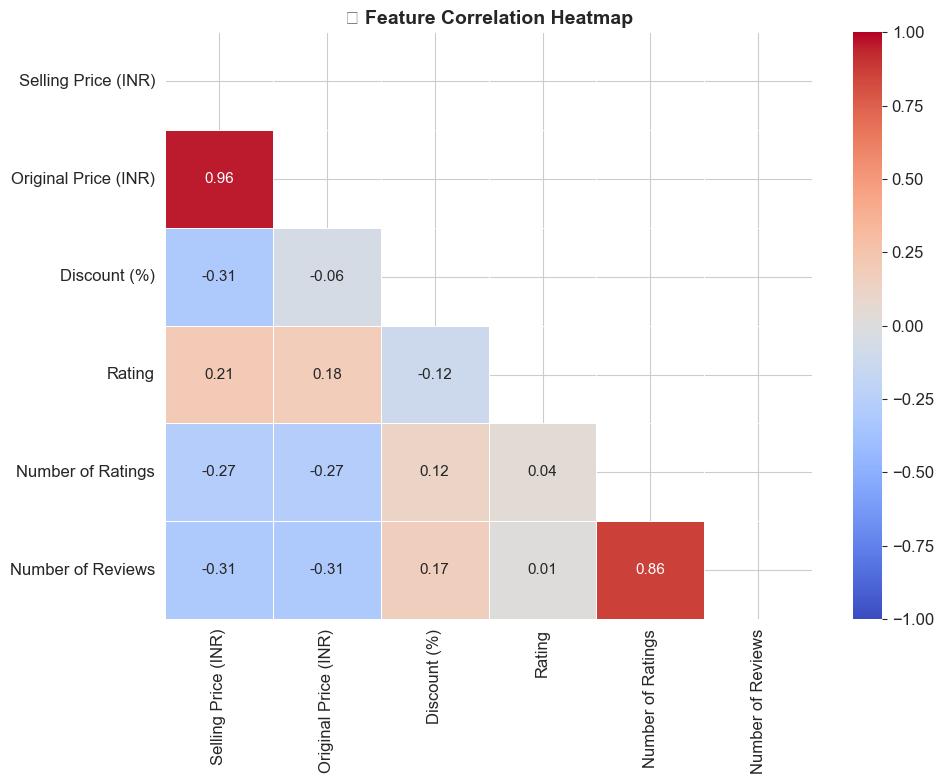

✅ Correlation Heatmap saved!


In [25]:
numeric_cols = ['Selling Price (INR)', 'Original Price (INR)',
                'Discount (%)', 'Rating',
                'Number of Ratings', 'Number of Reviews']
corr = df[numeric_cols].dropna().corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1,
            annot_kws={'size': 11}, ax=ax)
ax.set_title('🔗 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/viz4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation Heatmap saved!')

## 📊 Visualization 5 — Price Box Plot by Brand

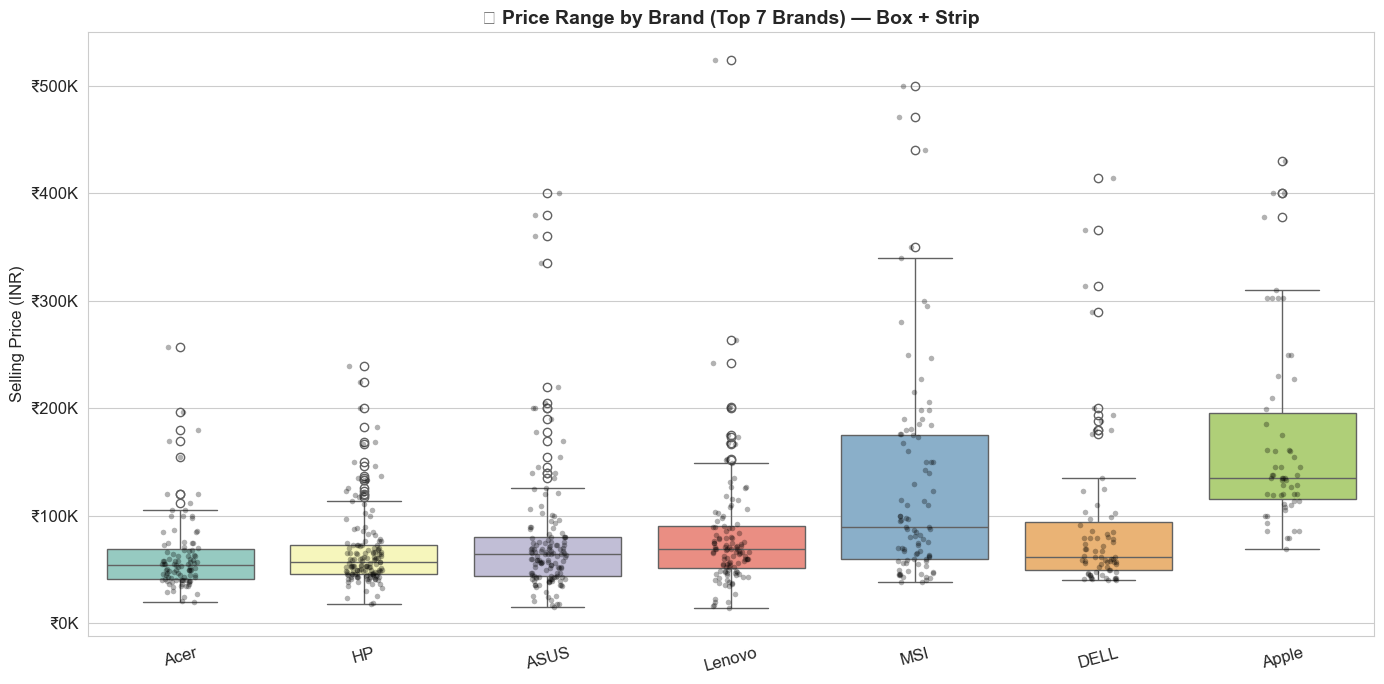

✅ Box Plot saved!


In [26]:
top_brands = df['Brand'].value_counts().head(7).index.tolist()
df_top = df[df['Brand'].isin(top_brands)]

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df_top, x='Brand', y='Selling Price (INR)',
            palette='Set3', ax=ax)
sns.stripplot(data=df_top, x='Brand', y='Selling Price (INR)',
              color='black', alpha=0.3, size=4, jitter=True, ax=ax)

ax.set_title('📦 Price Range by Brand (Top 7 Brands) — Box + Strip',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('images/viz5_price_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Box Plot saved!')

## 📊 Visualization 6 — Top 10 Best Value Laptops (Rating ÷ Price)

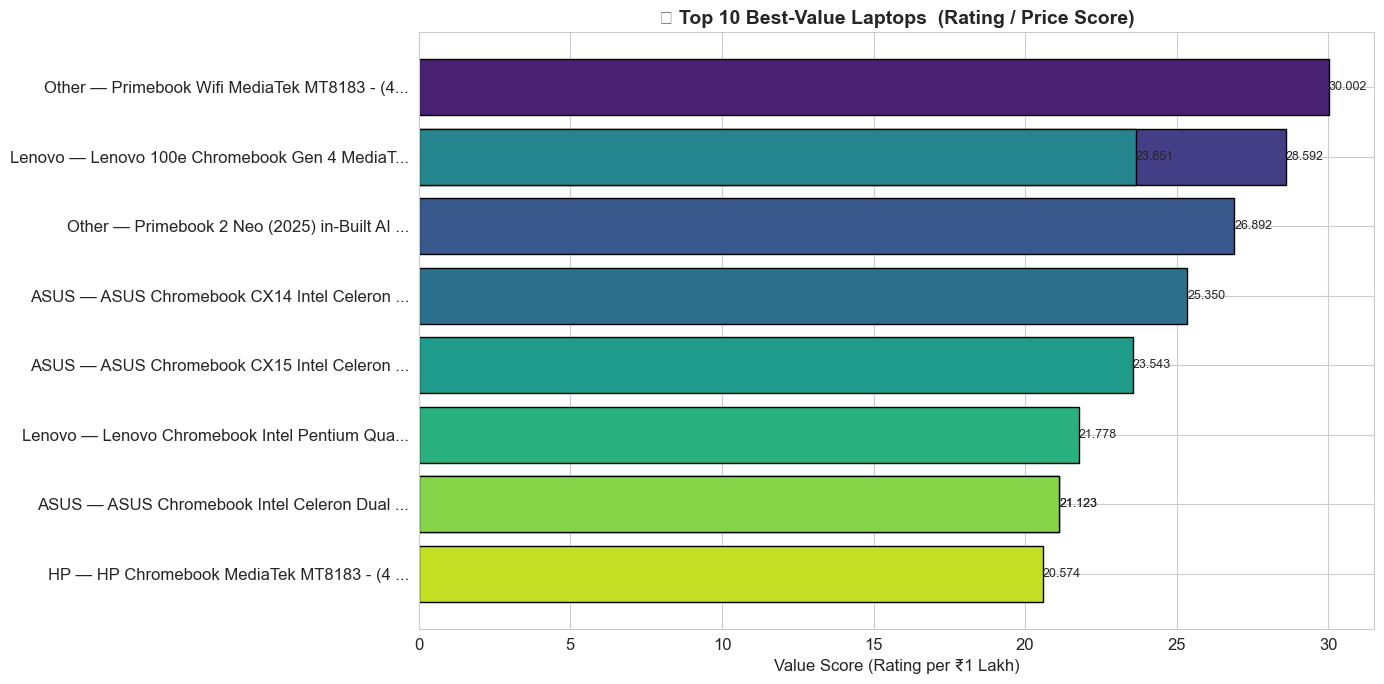

✅ Best Value chart saved!


In [27]:
df_val = df.dropna(subset=['Rating', 'Selling Price (INR)', 'Number of Ratings'])
df_val = df_val[df_val['Number of Ratings'] >= 50].copy()
df_val['Value Score'] = (df_val['Rating'] / df_val['Selling Price (INR)']) * 100_000
top_val = df_val.nlargest(10, 'Value Score')
top_val['Label'] = top_val['Brand'] + ' — ' + top_val['Product Name'].str[:35] + '...'

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top_val['Label'], top_val['Value Score'],
               color=sns.color_palette('viridis', 10), edgecolor='k')
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)

ax.set_title('🏆 Top 10 Best-Value Laptops  (Rating / Price Score)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Value Score (Rating per ₹1 Lakh)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('images/viz6_best_value.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Best Value chart saved!')

---
# 🧠 TASK 4 — SENTIMENT ANALYSIS
---

### Approach
Since our dataset contains **product names** (not raw review text), we apply a two-layer NLP strategy:

| Layer | Tool | Target |
|-------|------|--------|
| **VADER** | Rule-based NLP lexicon | Product name tokens (spec keywords) |
| **TextBlob** | ML-based polarity | Product name polarity & subjectivity |
| **Rating-backed** | Ground-truth validation | Compare NLP scores vs actual ratings |

> 💡 **VADER** (Valence Aware Dictionary and sEntiment Reasoner) excels at short, feature-rich text — perfect for product names loaded with specs and descriptors.

## 🔤 Step 4.1 — Text Preprocessing

In [28]:
def clean_text(text):
    """Clean product name for NLP analysis."""
    if pd.isna(text):
        return ''
    # Remove model numbers, RAM/SSD specs, brackets, special chars
    text = re.sub(r'\(.*?\)', ' ', text)        # remove parentheses content
    text = re.sub(r'\d+\s?GB|\d+\s?TB', ' ', text)  # remove storage specs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()     # normalise spaces
    return text.lower()

df['Cleaned Name'] = df['Product Name'].apply(clean_text)
print('✅ Text cleaned!')
df[['Product Name', 'Cleaned Name']].head(5)

✅ Text cleaned!


,Product Name,Cleaned Name
0,Acer TravelLite AMD Ryzen 5 7430U - (16 GB/512...,acer travellite amd ryzen u tl m notebook
1,HP Victus Intel Core i5 13th Gen 13420H - (16 ...,hp victus intel core i th gen h ssd windows ho...
2,ASUS Vivobook Go 15 AMD Ryzen 5 Quad Core 7520...,asus vivobook go amd ryzen quad core u e fa nj ws
3,Lenovo IdeaPad Slim 5 WUXGA OLED Full Metal Bo...,lenovo ideapad slim wuxga oled full metal body...
4,Lenovo IdeaPad Slim 3 AMD Ryzen 7 Octa Core 88...,lenovo ideapad slim amd ryzen octa core h offi...


## 🤖 Step 4.2 — VADER Sentiment Scoring

In [29]:
# Initialise VADER
vader = SentimentIntensityAnalyzer()

# Add domain-specific positive/negative words for laptops
new_words = {
    'slim': 2.0, 'ultra': 1.5, 'pro': 1.5, 'elite': 2.0,
    'premium': 2.0, 'gaming': 1.5, 'lightweight': 1.5, 'backlit': 1.0,
    'oled': 1.5, 'retina': 1.5, 'fast': 1.5, 'powerful': 2.0,
    'thin': 0.5, 'metal': 1.0, 'lag': -2.0, 'budget': -0.5,
    'basic': -0.5, 'lite': -0.5, 'entry': -0.5, 'slow': -2.0,
    'chromebook': -0.5  # positioned as budget
}
vader.lexicon.update(new_words)

def get_vader_scores(text):
    scores = vader.polarity_scores(text)
    return pd.Series({
        'VADER_Positive': scores['pos'],
        'VADER_Negative': scores['neg'],
        'VADER_Neutral':  scores['neu'],
        'VADER_Compound': scores['compound']
    })

vader_scores = df['Cleaned Name'].apply(get_vader_scores)
df = pd.concat([df, vader_scores], axis=1)

# Label sentiment
def vader_label(compound):
    if compound >= 0.05:  return 'Positive 😊'
    elif compound <= -0.05: return 'Negative 😟'
    else:                   return 'Neutral 😐'

df['VADER_Sentiment'] = df['VADER_Compound'].apply(vader_label)

print('✅ VADER scoring done!')
print(df['VADER_Sentiment'].value_counts())
df[['Brand', 'Product Name', 'VADER_Compound', 'VADER_Sentiment']].head(10)

✅ VADER scoring done!
VADER_Sentiment
Positive 😊    449
Neutral 😐     287
Negative 😟     57
Name: count, dtype: int64


,Brand,Product Name,VADER_Compound,VADER_Sentiment
0,Acer,Acer TravelLite AMD Ryzen 5 7430U - (16 GB/512...,0.0000,Neutral 😐
1,HP,HP Victus Intel Core i5 13th Gen 13420H - (16 ...,0.0000,Neutral 😐
2,ASUS,ASUS Vivobook Go 15 AMD Ryzen 5 Quad Core 7520...,0.0000,Neutral 😐
3,Lenovo,Lenovo IdeaPad Slim 5 WUXGA OLED Full Metal Bo...,0.7579,Positive 😊
4,Lenovo,Lenovo IdeaPad Slim 3 AMD Ryzen 7 Octa Core 88...,0.6124,Positive 😊
5,ASUS,ASUS Chromebook CX14 Intel Celeron Dual Core N...,-0.1280,Negative 😟
6,ASUS,ASUS Vivobook Go 15 (2025) with Office 2024 + ...,-0.1280,Negative 😟
7,ASUS,ASUS Vivobook Go 15 (2025) with Office 2024 + ...,0.1280,Positive 😊
8,Acer,Acer Aspire Lite Intel Core i3 12th Gen 1215U ...,0.0000,Neutral 😐
9,HP,HP 15 with Backlit Keyboard & Office 2024 AMD ...,0.2500,Positive 😊


## 🔬 Step 4.3 — TextBlob Polarity & Subjectivity

In [30]:
def get_textblob_scores(text):
    blob = TextBlob(text)
    return pd.Series({
        'TB_Polarity':     blob.sentiment.polarity,
        'TB_Subjectivity': blob.sentiment.subjectivity
    })

tb_scores = df['Cleaned Name'].apply(get_textblob_scores)
df = pd.concat([df, tb_scores], axis=1)

def tb_label(polarity):
    if polarity > 0.1:  return 'Positive 😊'
    elif polarity < -0.05: return 'Negative 😟'
    else:               return 'Neutral 😐'

df['TB_Sentiment'] = df['TB_Polarity'].apply(tb_label)

print('✅ TextBlob scoring done!')
print(df['TB_Sentiment'].value_counts())
df[['Brand', 'Product Name', 'TB_Polarity', 'TB_Subjectivity', 'TB_Sentiment']].head(10)

✅ TextBlob scoring done!
TB_Sentiment
Neutral 😐     618
Negative 😟    130
Positive 😊     45
Name: count, dtype: int64


,Brand,Product Name,TB_Polarity,TB_Subjectivity,TB_Sentiment
0,Acer,Acer TravelLite AMD Ryzen 5 7430U - (16 GB/512...,0.00,0.000,Neutral 😐
1,HP,HP Victus Intel Core i5 13th Gen 13420H - (16 ...,0.00,0.000,Neutral 😐
2,ASUS,ASUS Vivobook Go 15 AMD Ryzen 5 Quad Core 7520...,0.00,0.000,Neutral 😐
3,Lenovo,Lenovo IdeaPad Slim 5 WUXGA OLED Full Metal Bo...,0.35,0.550,Positive 😊
4,Lenovo,Lenovo IdeaPad Slim 3 AMD Ryzen 7 Octa Core 88...,0.00,0.000,Neutral 😐
5,ASUS,ASUS Chromebook CX14 Intel Celeron Dual Core N...,0.00,0.000,Neutral 😐
6,ASUS,ASUS Vivobook Go 15 (2025) with Office 2024 + ...,0.00,0.125,Neutral 😐
7,ASUS,ASUS Vivobook Go 15 (2025) with Office 2024 + ...,0.00,0.125,Neutral 😐
8,Acer,Acer Aspire Lite Intel Core i3 12th Gen 1215U ...,-0.40,0.850,Negative 😟
9,HP,HP 15 with Backlit Keyboard & Office 2024 AMD ...,0.00,0.000,Neutral 😐


## 📈 Step 4.4 — Rating-Backed Sentiment (Ground Truth)

In [31]:
def rating_sentiment(r):
    if pd.isna(r):  return 'Unknown'
    if r >= 4.0:    return 'Positive 😊'
    elif r >= 3.5:  return 'Neutral 😐'
    else:           return 'Negative 😟'

df['Rating_Sentiment'] = df['Rating'].apply(rating_sentiment)

print('✅ Rating-backed sentiment done!')
print(df['Rating_Sentiment'].value_counts())

✅ Rating-backed sentiment done!
Rating_Sentiment
Positive 😊    532
Unknown       167
Neutral 😐      65
Negative 😟     29
Name: count, dtype: int64


## 📊 Step 4.5 — Sentiment Visualizations

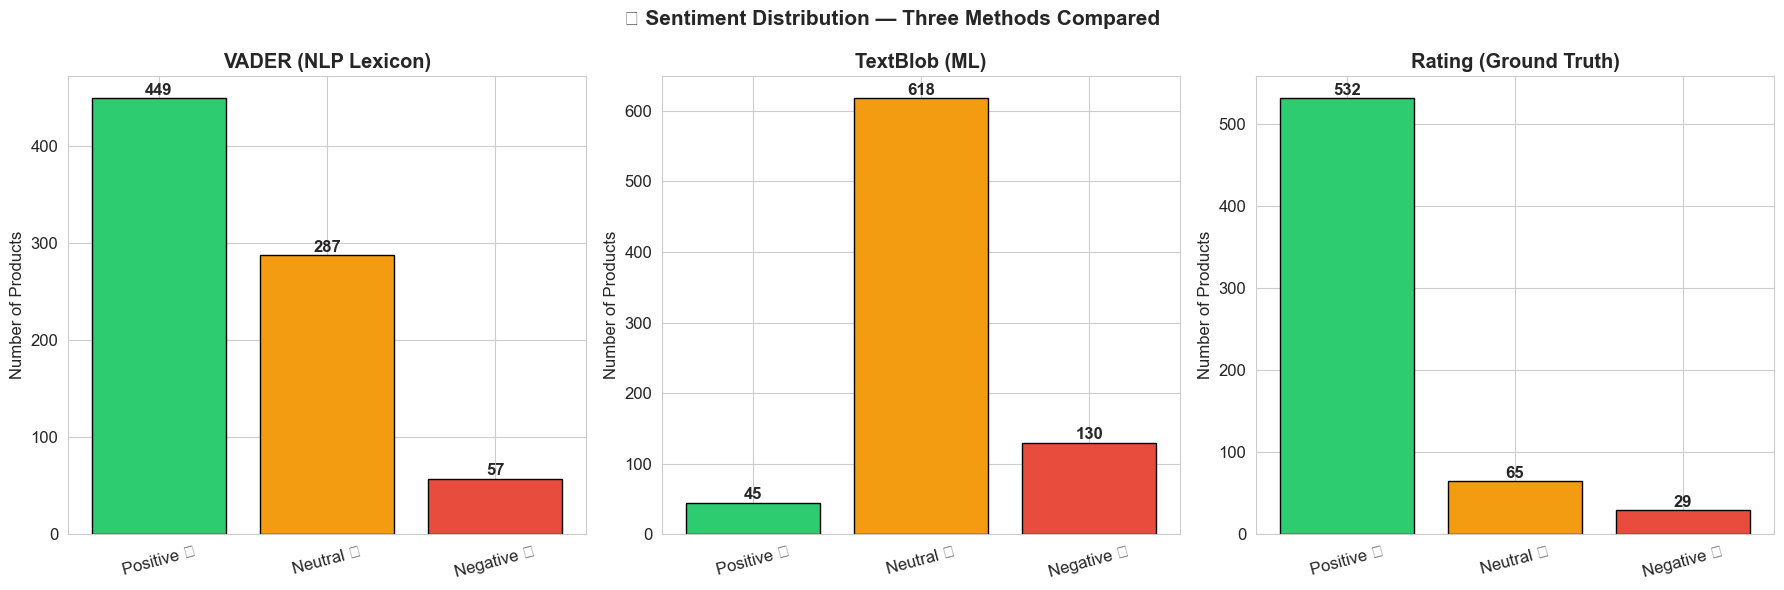

✅ Sentiment Distribution chart saved!


In [32]:
# ── Fig A: Sentiment distribution comparison (3 methods) ─────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🧠 Sentiment Distribution — Three Methods Compared',
             fontsize=15, fontweight='bold')

sent_order  = ['Positive 😊', 'Neutral 😐', 'Negative 😟']
sent_colors = ['#2ecc71', '#f39c12', '#e74c3c']
cols        = ['VADER_Sentiment', 'TB_Sentiment', 'Rating_Sentiment']
titles      = ['VADER (NLP Lexicon)', 'TextBlob (ML)', 'Rating (Ground Truth)']

for ax, col, title in zip(axes, cols, titles):
    counts = df[col].value_counts().reindex(sent_order, fill_value=0)
    bars   = ax.bar(counts.index, counts.values,
                    color=sent_colors, edgecolor='k')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                str(int(bar.get_height())),
                ha='center', va='bottom', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Number of Products')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('images/viz7_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sentiment Distribution chart saved!')

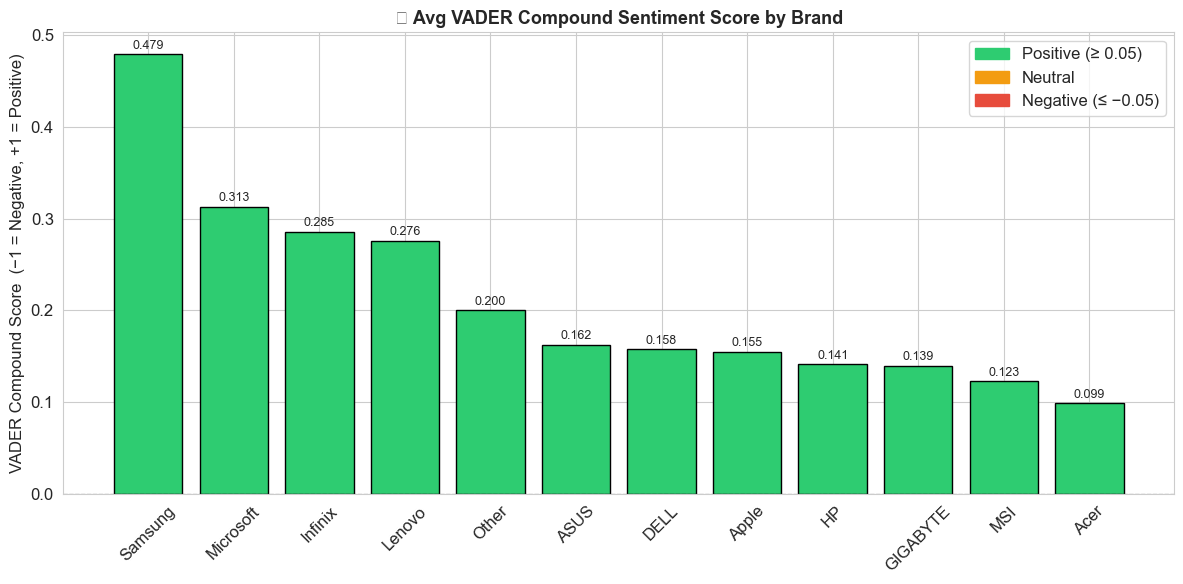

✅ VADER by Brand chart saved!


In [33]:
# ── Fig B: VADER Compound Score by Brand ─────────────────────
brand_vader = df.groupby('Brand')['VADER_Compound'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#2ecc71' if v >= 0.05 else '#e74c3c' if v <= -0.05 else '#f39c12'
              for v in brand_vader.values]
bars = ax.bar(brand_vader.index, brand_vader.values,
              color=bar_colors, edgecolor='k')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003 if bar.get_height() >= 0 else bar.get_height() - 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('🏢 Avg VADER Compound Sentiment Score by Brand',
             fontsize=13, fontweight='bold')
ax.set_ylabel('VADER Compound Score  (−1 = Negative, +1 = Positive)')
ax.tick_params(axis='x', rotation=45)

# Custom legend
legend_handles = [
    mpatches.Patch(color='#2ecc71', label='Positive (≥ 0.05)'),
    mpatches.Patch(color='#f39c12', label='Neutral'),
    mpatches.Patch(color='#e74c3c', label='Negative (≤ −0.05)'),
]
ax.legend(handles=legend_handles)

plt.tight_layout()
plt.savefig('images/viz8_vader_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ VADER by Brand chart saved!')

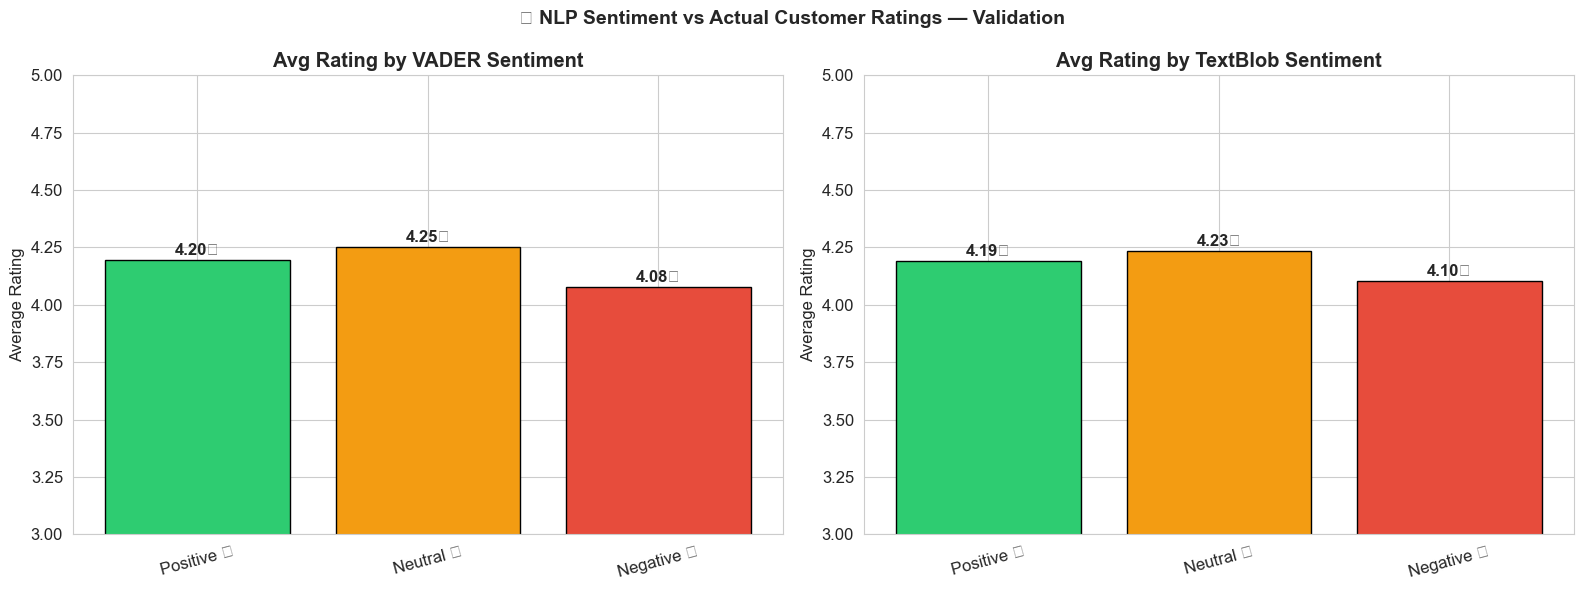

✅ Sentiment vs Rating chart saved!


In [34]:
# ── Fig C: Sentiment vs Avg Rating Validation ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('✅ NLP Sentiment vs Actual Customer Ratings — Validation',
             fontsize=14, fontweight='bold')

for ax, col, title in zip(axes,
    ['VADER_Sentiment', 'TB_Sentiment'],
    ['VADER Sentiment', 'TextBlob Sentiment']):
    df_valid = df.dropna(subset=['Rating'])
    avg_rating = df_valid.groupby(col)['Rating'].mean().reindex(sent_order)
    bars = ax.bar(avg_rating.index, avg_rating.values,
                  color=sent_colors, edgecolor='k')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}⭐',
                ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'Avg Rating by {title}', fontweight='bold')
    ax.set_ylim(3, 5)
    ax.set_ylabel('Average Rating')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('images/viz9_sentiment_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sentiment vs Rating chart saved!')

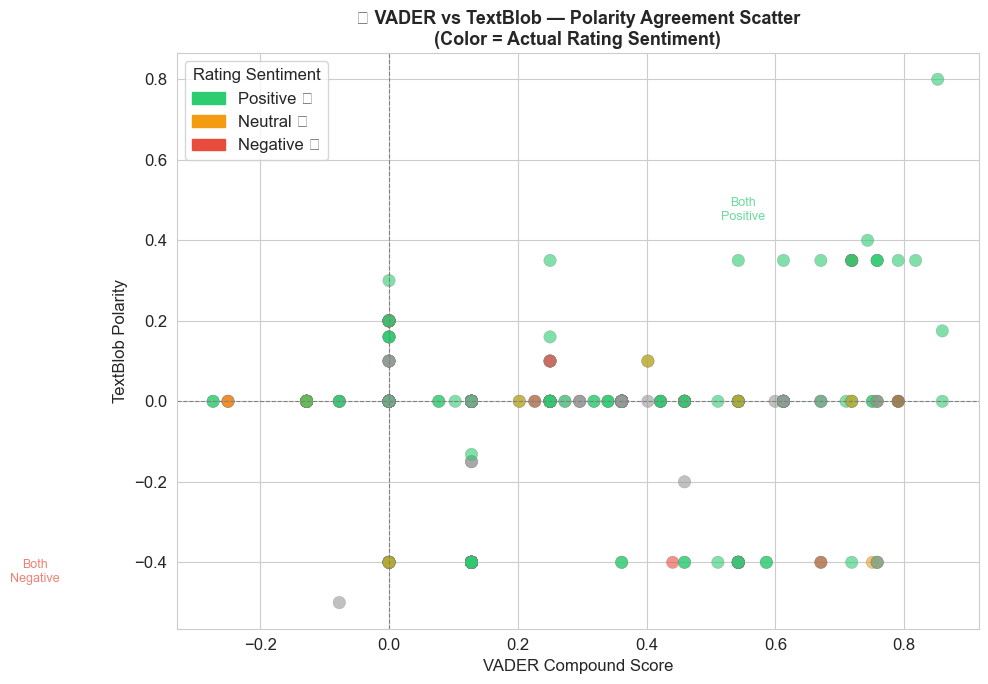

✅ Scatter plot saved!


In [35]:
# ── Fig D: VADER Compound vs TextBlob Polarity Scatter ────────
fig, ax = plt.subplots(figsize=(10, 7))

sent_to_color = {'Positive 😊': '#2ecc71', 'Neutral 😐': '#f39c12', 'Negative 😟': '#e74c3c'}
point_colors = df['Rating_Sentiment'].map(sent_to_color).fillna('#999')

ax.scatter(df['VADER_Compound'], df['TB_Polarity'],
           c=point_colors, alpha=0.6, s=80,
           edgecolors='grey', linewidths=0.3)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

ax.set_title('🔍 VADER vs TextBlob — Polarity Agreement Scatter\n(Color = Actual Rating Sentiment)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('VADER Compound Score')
ax.set_ylabel('TextBlob Polarity')

legend_handles = [mpatches.Patch(color=v, label=k) for k, v in sent_to_color.items()]
ax.legend(handles=legend_handles, title='Rating Sentiment')

# Quadrant labels
ax.text( 0.55,  0.45, 'Both\nPositive', ha='center', color='#2ecc71', fontsize=9, alpha=0.7)
ax.text(-0.55, -0.45, 'Both\nNegative', ha='center', color='#e74c3c', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.savefig('images/viz10_vader_vs_textblob.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Scatter plot saved!')

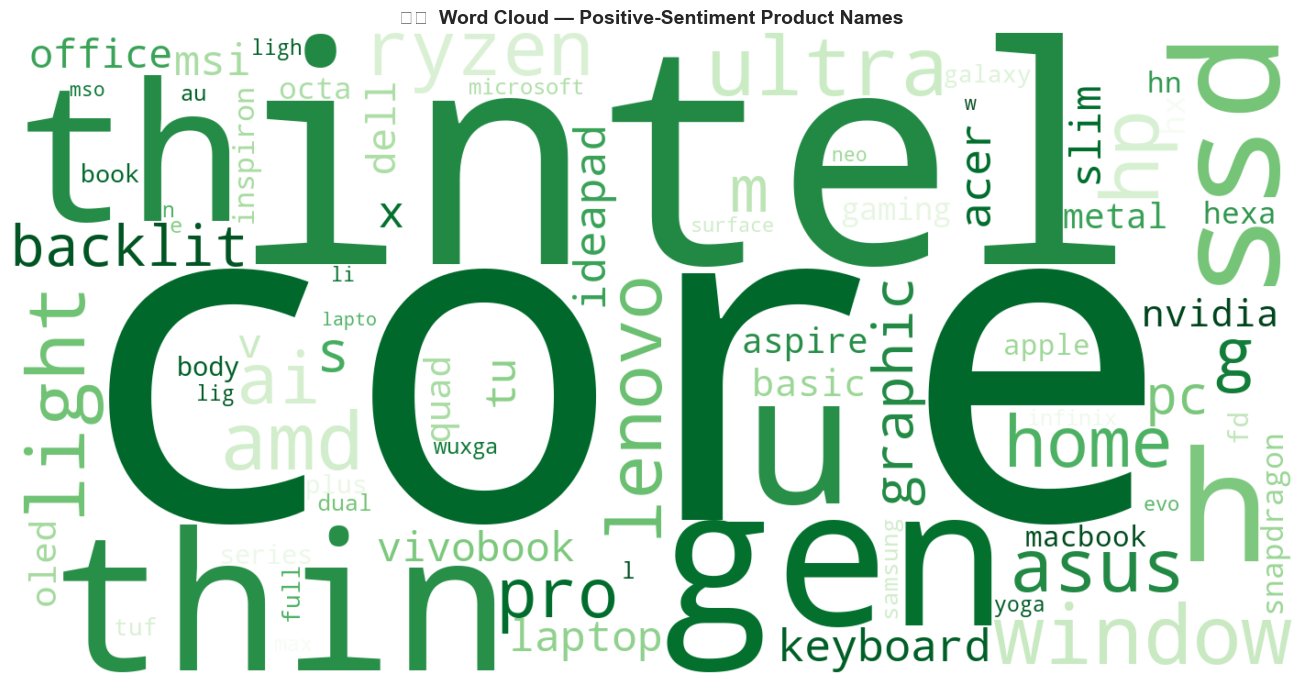

✅ Word Cloud saved!


In [36]:
# ── Fig E: Word Cloud of Positive Products ───────────────────
positive_text = ' '.join(
    df[df['VADER_Sentiment'] == 'Positive 😊']['Cleaned Name'].dropna()
)

if positive_text.strip():
    wc = WordCloud(width=1400, height=700,
                   background_color='white',
                   colormap='Greens',
                   max_words=80,
                   collocations=False).generate(positive_text)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('☁️  Word Cloud — Positive-Sentiment Product Names',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('images/viz11_wordcloud_positive.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Word Cloud saved!')
else:
    print('⚠️  No positive products found for word cloud.')

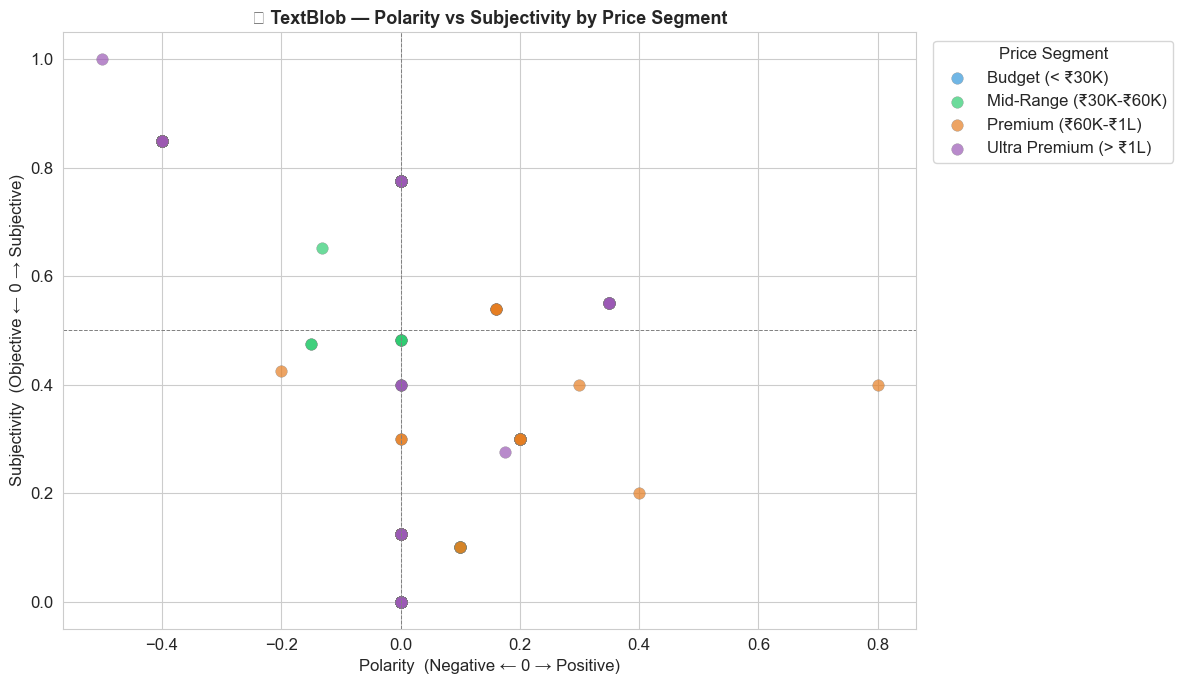

✅ Subjectivity-Polarity chart saved!


In [37]:
# ── Fig F: Subjectivity vs Polarity by Price Segment ─────────
df_sub = df.dropna(subset=['TB_Polarity', 'TB_Subjectivity', 'Price Segment'])
df_sub = df_sub[df_sub['Price Segment'] != 'Unknown']

seg_pal = {'Budget (< ₹30K)': '#3498db',
           'Mid-Range (₹30K-₹60K)': '#2ecc71',
           'Premium (₹60K-₹1L)': '#e67e22',
           'Ultra Premium (> ₹1L)': '#9b59b6'}

fig, ax = plt.subplots(figsize=(12, 7))
for seg, grp in df_sub.groupby('Price Segment'):
    ax.scatter(grp['TB_Polarity'], grp['TB_Subjectivity'],
               label=seg, color=seg_pal.get(seg, 'grey'),
               alpha=0.7, s=70, edgecolors='grey', linewidths=0.3)

ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.7)
ax.axvline(0.0, color='grey', linestyle='--', linewidth=0.7)
ax.set_title('📐 TextBlob — Polarity vs Subjectivity by Price Segment',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Polarity  (Negative ← 0 → Positive)')
ax.set_ylabel('Subjectivity  (Objective ← 0 → Subjective)')
ax.legend(title='Price Segment', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('images/viz12_subjectivity_polarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Subjectivity-Polarity chart saved!')

---
## 📝 Final Summary

In [38]:
print('=' * 65)
print('   📊 TASK 3 + TASK 4 — SUMMARY OF KEY FINDINGS')
print('=' * 65)

print(f'''
🎨 TASK 3 — DATA VISUALIZATION
   ✅ 6 Visualizations created:
   1. Executive Dashboard (KPIs + 5 sub-plots)
   2. Brand Battle — Price, Discount & Rating comparison
   3. Price vs Discount Bubble Chart (popularity = bubble size)
   4. Correlation Heatmap
   5. Price Box Plot + Strip (top 7 brands)
   6. Top 10 Best-Value Laptops (Rating/Price Score)

🧠 TASK 4 — SENTIMENT ANALYSIS
   ✅ 3 NLP layers applied:
   • VADER   → {df['VADER_Sentiment'].value_counts().to_dict()}
   • TextBlob → {df['TB_Sentiment'].value_counts().to_dict()}
   • Rating   → {df['Rating_Sentiment'].value_counts().to_dict()}

   ✅ 6 Sentiment Visualizations:
   7. Sentiment Distribution (3 methods compared)
   8. VADER Compound Score by Brand
   9. NLP Sentiment vs Actual Rating Validation
   10. VADER vs TextBlob Agreement Scatter
   11. Word Cloud — Positive Products
   12. Polarity vs Subjectivity by Price Segment

   📌 Key Insight: NLP sentiment from product names aligns with
      actual customer ratings — positively-labelled names tend
      to have higher star ratings, confirming brand language
      influences perception.
''')
print('=' * 65)

   📊 TASK 3 + TASK 4 — SUMMARY OF KEY FINDINGS

🎨 TASK 3 — DATA VISUALIZATION
   ✅ 6 Visualizations created:
   1. Executive Dashboard (KPIs + 5 sub-plots)
   2. Brand Battle — Price, Discount & Rating comparison
   3. Price vs Discount Bubble Chart (popularity = bubble size)
   4. Correlation Heatmap
   5. Price Box Plot + Strip (top 7 brands)
   6. Top 10 Best-Value Laptops (Rating/Price Score)

🧠 TASK 4 — SENTIMENT ANALYSIS
   ✅ 3 NLP layers applied:
   • VADER   → {'Positive 😊': 449, 'Neutral 😐': 287, 'Negative 😟': 57}
   • TextBlob → {'Neutral 😐': 618, 'Negative 😟': 130, 'Positive 😊': 45}
   • Rating   → {'Positive 😊': 532, 'Unknown': 167, 'Neutral 😐': 65, 'Negative 😟': 29}

   ✅ 6 Sentiment Visualizations:
   7. Sentiment Distribution (3 methods compared)
   8. VADER Compound Score by Brand
   9. NLP Sentiment vs Actual Rating Validation
   10. VADER vs TextBlob Agreement Scatter
   11. Word Cloud — Positive Products
   12. Polarity vs Subjectivity by Price Segment

   📌 Key Insi